In [1]:
import tensorflow as tf
import numpy as np
import os
import zipfile
import cv2  
import matplotlib.pyplot as plt 
import gc 
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split
from tensorflow.keras.applications import EfficientNetB0, InceptionV3, Xception
from tensorflow.keras.applications.xception import preprocess_input as inception_preprocess
from tensorflow.keras.applications.efficientnet import preprocess_input as effnet_preprocess
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical

In [2]:
zip_path = "archive.zip"
extract_to = "dataset" 

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_to)

print("Dataset extracted successfully.")
print("Extracted folders:")
print(os.listdir("dataset"))
train_dir = tf.keras.utils.image_dataset_from_directory(
    "dataset/training",
    image_size=(224, 224),
    batch_size=32
)

test_dir = tf.keras.utils.image_dataset_from_directory(
    "dataset/testing",
    image_size=(224, 224),
    batch_size=32
)
print("Training classes:", train_dir.class_names)

print("Testing classes:", test_dir.class_names)



Dataset extracted successfully.
Extracted folders:
['Testing', 'Training']
Found 5712 files belonging to 4 classes.
Found 1311 files belonging to 4 classes.
Training classes: ['glioma', 'meningioma', 'notumor', 'pituitary']
Testing classes: ['glioma', 'meningioma', 'notumor', 'pituitary']


In [3]:
def crop_img_vis(img, padding=10):
    

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    gray = cv2.GaussianBlur(gray, (5, 5), 0)

    thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)[1]

    thresh = cv2.erode(thresh, None, iterations=2)
    thresh = cv2.dilate(thresh, None, iterations=2)
    
    contours, _ = cv2.findContours(thresh.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    
    if not contours:
       
        return img, [img, img, img, img]

    c = max(contours, key=cv2.contourArea)
    

    step1_img = img.copy()
    step2_img = img.copy()
    cv2.drawContours(step2_img, [c], -1, (0, 255, 255), 3)

    extLeft = tuple(c[c[:, :, 0].argmin()][0])
    extRight = tuple(c[c[:, :, 0].argmax()][0])
    extTop = tuple(c[c[:, :, 1].argmin()][0])
    extBot = tuple(c[c[:, :, 1].argmax()][0])
    
    step3_img = step2_img.copy()
    cv2.circle(step3_img, extLeft, 8, (0, 0, 255), -1)
    cv2.circle(step3_img, extRight, 8, (0, 255, 0), -1)
    cv2.circle(step3_img, extTop, 8, (255, 0, 0), -1)
    cv2.circle(step3_img, extBot, 8, (255, 255, 0), -1)

  
    h, w, _ = img.shape
    x1 = max(0, extLeft[0] - padding)
    y1 = max(0, extTop[1] - padding)
    x2 = min(w, extRight[0] + padding)
    y2 = min(h, extBot[1] + padding)
    
    final_crop = img[y1:y2, x1:x2]
    
   
    if final_crop.size == 0:
        return img, [img, img, img, img]

    return final_crop, [step1_img, step2_img, step3_img, final_crop]

In [4]:
IMG_SIZE = (224, 224)
def load_data_from_dir(data_dir, class_names):
    images, labels_list = [], []
    label_map = {name: i for i, name in enumerate(class_names)}
    print(f"Loading data from: {data_dir}")

    for class_name in class_names:
        class_path = os.path.join(data_dir, class_name)
        if not os.path.isdir(class_path): continue
        for img_file in os.listdir(class_path):
            img_path = os.path.join(class_path, img_file)
            image = cv2.imread(img_path)
            if image is None: continue
            
            # Preprocessing without exception handling
            cropped_bgr, _ = crop_img_vis(image)
            if cropped_bgr.size == 0: cropped_bgr = image
            gray_image = cv2.cvtColor(cropped_bgr, cv2.COLOR_BGR2GRAY)
            image = cv2.bilateralFilter(gray_image, 2, 50, 50)
            final_image_bgr = cv2.applyColorMap(gray_image, cv2.COLORMAP_BONE)
            resized_image_bgr = cv2.resize(final_image_bgr, IMG_SIZE)
            images.append(resized_image_bgr)
            labels_list.append(label_map[class_name])

    return np.array(images), np.array(labels_list)

In [5]:
train_dir = "dataset/training"
test_dir = "dataset/testing"
class_names = sorted(os.listdir(train_dir))
print(f"Found classes: {class_names}")

Found classes: ['glioma', 'meningioma', 'notumor', 'pituitary']


In [6]:
xtrain, ytrain = load_data_from_dir(train_dir, class_names)
X_temp, y_temp = load_data_from_dir(test_dir, class_names)
xval, X_test, yval, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)



Loading data from: dataset/training
Loading data from: dataset/testing


In [7]:
ytrain = to_categorical(ytrain, num_classes=4)
ytest = to_categorical(y_test, num_classes=4)
yval = to_categorical(yval, num_classes=4)

In [8]:

xtrain_eff = effnet_preprocess(xtrain)
xtest_eff = effnet_preprocess(X_test)
xval_eff = effnet_preprocess(xval)

base_model = EfficientNetB0(
    include_top=False,
    input_shape=(224, 224, 3),
    weights='imagenet'
)

base_model.trainable = False  
for layer in base_model.layers[-30:]:
    layer.trainable = True

x = layers.GlobalAveragePooling2D()(base_model.output)
x = layers.Dense(250, activation='relu')(x)
x = layers.Dropout(0.4)(x)
x = layers.Dense(100, activation='relu')(x)
x = layers.Dropout(0.4)(x)
x = layers.Dense(25, activation='relu')(x)
predict = layers.Dense(4, activation='softmax')(x)


model_effnet = models.Model(inputs=base_model.input, outputs=predict)


model_effnet.compile(optimizer=Adam(learning_rate=0.0001),
                     loss='categorical_crossentropy',
                     metrics=['accuracy'])

model_effnet.load_weights("25 epochs efficentnet aug.h5")




In [9]:
val_loss, val_accuracy = model_effnet.evaluate(xval_eff, yval, verbose=0)

print(f"Validation Accuracy: {val_accuracy * 100:.2f}%")

Validation Accuracy: 99.39%


In [10]:
from tensorflow.keras.applications.xception import preprocess_input as xception_preprocess

xtrain_incep = inception_preprocess(xtrain)
xtest_incep = inception_preprocess(X_test)
xval_incep = inception_preprocess(xval)

xtrain_xcep = xception_preprocess(xtrain)
xtest_xcep = xception_preprocess(X_test)
xval_xcep= xception_preprocess(xval)

In [11]:
model_inception = models.load_model("25_epochs_weights_new_inception.h5")
model_xception = models.load_model("25_epochs_weights_xception.h5")



In [12]:
val_loss_incep, val_accuracy_incep = model_inception.evaluate(xval_incep, yval, verbose=0)
val_loss_xcep, val_accuracy_xcep = model_xception.evaluate(xval_xcep, yval, verbose=0)

print(f"Inception Model Validation Accuracy: {val_accuracy_incep * 100:.2f}%")
print(f"Xception Model Validation Accuracy: {val_accuracy_xcep * 100:.2f}%")

Inception Model Validation Accuracy: 98.02%
Xception Model Validation Accuracy: 99.39%


In [13]:
preds_effnet = model_effnet.predict(xtest_eff)
preds_inception = model_inception.predict(xtest_incep)
preds_xception = model_xception.predict(xtest_xcep)

21/21 [==============================] - 5s 124ms/step


In [14]:
acc_effnet = accuracy_score(y_test, np.argmax(preds_effnet, axis=1))
acc_inception = accuracy_score(y_test, np.argmax(preds_inception, axis=1))
acc_xception = accuracy_score(y_test, np.argmax(preds_xception, axis=1))
print(f"  - EfficientNetB0: {acc_effnet:.4f}")
print(f"  - InceptionV3:    {acc_inception:.4f}")
print(f"  - Xception:       {acc_xception:.4f}")

  - EfficientNetB0: 0.9909
  - InceptionV3:    0.9893
  - Xception:       0.9924


In [15]:
val_accuracies = [val_accuracy,val_accuracy_incep ,val_accuracy_xcep] 
total_accuracy = sum(val_accuracies)
weights = [acc / total_accuracy for acc in val_accuracies]
print(f"\nweights based on validation accuracies: {weights}")


weights based on validation accuracies: [0.33487654565824754, 0.3302469086835049, 0.33487654565824754]


In [16]:

ensemble_preds_probs = (weights[0] * preds_effnet +
                        weights[1] * preds_inception +
                        weights[2] * preds_xception)


ensemble_final_preds = np.argmax(ensemble_preds_probs, axis=1)
ytest_labels = np.argmax(ytest, axis=1)

acc_ensemble = accuracy_score(ytest_labels, ensemble_final_preds)

print(f"Ensemble Test Accuracy: {acc_ensemble * 100:.2f}%")

Ensemble Test Accuracy: 99.39%


In [17]:
print("\n--- DETAILED REPORT FOR WEIGHTED ENSEMBLE ---")
print(classification_report(ytest_labels, ensemble_final_preds, target_names=class_names,digits=6))


--- DETAILED REPORT FOR WEIGHTED ENSEMBLE ---
              precision    recall  f1-score   support

      glioma   1.000000  0.980000  0.989899       150
  meningioma   0.987013  0.993464  0.990228       153
     notumor   1.000000  1.000000  1.000000       203
   pituitary   0.986842  1.000000  0.993377       150

    accuracy                       0.993902       656
   macro avg   0.993464  0.993366  0.993376       656
weighted avg   0.993962  0.993902  0.993897       656



In [18]:
def plot_confusion_matrix(y_true, y_pred, class_names, title="Confusion Matrix"):
    cm = confusion_matrix(y_true, y_pred)
    fig = plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title(title)
    plt.ylabel('Actual Label')
    plt.xlabel('Predicted Label')
    
    
    filename = f"{title.replace(' ', '_')}.png"
    plt.savefig(filename)
    print(f" Confusion matrix saved to '{filename}'")
   
    
    plt.show()

 Confusion matrix saved to 'Confusion_Matrix_for_Original_Test_Set_new_with_aug.png'


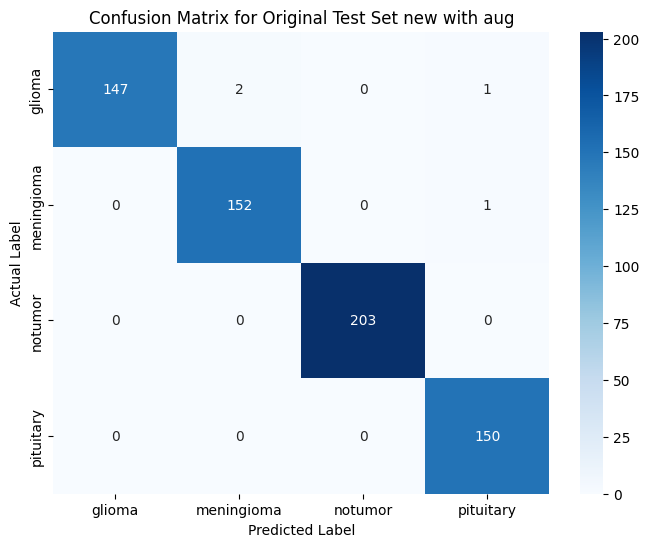

In [19]:
import seaborn as sns 
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
plot_confusion_matrix(ytest_labels, ensemble_final_preds, class_names, title="Confusion Matrix for Original Test Set new with aug")